In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

# 타임스텝 수 설정
timesteps = 200

# DDIM에서는 여전히 베타 스케줄을 사용하지만, 샘플링은 다름
beta = torch.linspace(0.0001, 0.02, timesteps)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)
sqrt_alpha_bar = torch.sqrt(alpha_bar)
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)

# DDIM sampling을 위한 eta (0이면 Deterministic DDIM)
eta = 0.0

In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        half_dim = dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        self.register_buffer('emb', torch.exp(torch.arange(half_dim) * -emb_scale))

    def forward(self, t):
        """
        주어진 시간 스텝 t에 대해 sinusoidal embedding 생성
        """
        emb = t[:, None] * self.emb[None, :].to(t.device)
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
        )

        # 입력과 출력 채널이 다를 경우 skip 연결용 1x1 conv
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t):
        """
        x: 이미지 feature map
        t: 시간 임베딩
        """
        h = self.block1(x)
        time_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)
        h = h + time_emb
        h = self.block2(h)
        return h + self.residual_conv(x)

In [ ]:
class SimpleUNet(nn.Module):
    def __init__(self, time_dim=256):
        super().__init__()
        self.time_embed = TimeEmbedding(time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.conv0 = nn.Conv2d(1, 64, 3, padding=1)
        self.res1 = ResidualBlock(64, 128, time_dim)
        self.res2 = ResidualBlock(128, 128, time_dim)
        self.res3 = ResidualBlock(128, 64, time_dim)
        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t = self.time_embed(t)
        t = self.time_mlp(t)
        x = self.conv0(x)
        x = self.res1(x, t)
        x = self.res2(x, t)
        x = self.res3(x, t)
        return self.out(x)

In [ ]:
@torch.no_grad()
def ddim_sample(model, shape, device, eta=0.0):
    """
    DDIM 방식으로 샘플링 수행
    - eta=0.0이면 deterministic sampling
    - shape: [batch, channel, height, width]
    """
    x = torch.randn(shape, device=device)
    for i in reversed(range(1, timesteps)):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        alpha_t = alpha[i]
        alpha_bar_t = alpha_bar[i]
        alpha_bar_prev = alpha_bar[i - 1] if i > 1 else torch.tensor(1.0)

        # 예측된 노이즈
        pred_noise = model(x, t)

        # x0 복원 (reverse direction)
        x0 = (x - (1 - alpha_t).sqrt() * pred_noise) / alpha_t.sqrt()

        # DDIM 수정된 예측
        sigma = eta * ((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_t / alpha_bar_prev)).sqrt()
        noise = torch.randn_like(x) if i > 1 else 0
        x = alpha_bar_prev.sqrt() * x0 + (1 - alpha_bar_prev - sigma ** 2).sqrt() * pred_noise + sigma * noise

    return x

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),  # (0,1) 범위로 정규화됨
    transforms.Lambda(lambda x: x - 0.5),  # [-0.5, 0.5]로 스케일 조정 (Diffusion 모델 특성상)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.84MB/s]


In [ ]:
class DDIMTrainer:
    def __init__(self, model, timesteps=200, eta=0.0):
        self.model = model
        self.timesteps = timesteps
        self.eta = eta

        self.device = next(model.parameters()).device

        self.alpha = (1. - beta).to(self.device)
        self.alpha_bar = torch.cumprod(self.alpha, dim=0).to(self.device)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar).to(self.device)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar).to(self.device)

        self.loss_fn = nn.MSELoss()
    def train_step(self, x):
        """
        하나의 배치에 대해 forward → loss 계산 → backward
        """
        b = x.shape[0]
        t = torch.randint(0, self.timesteps, (b,), device=self.device).long()
        noise = torch.randn_like(x)

        sqrt_ab = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_1m_ab = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)

        x_noisy = sqrt_ab * x + sqrt_1m_ab * noise

        pred_noise = self.model(x_noisy, t)
        loss = self.loss_fn(pred_noise, noise)
        return loss

    @torch.no_grad()
    def sample_ddim(self, shape):
        """
        DDIM 방식으로 샘플링 (deterministic 가능)
        """
        b = shape[0]
        img = torch.randn(shape).to(self.device)

        for i in reversed(range(0, self.timesteps)):
            t = torch.full((b,), i, device=self.device, dtype=torch.long)
            alpha_t = self.alpha[t].view(-1, 1, 1, 1)
            alpha_bar_t = self.alpha_bar[t].view(-1, 1, 1, 1)
            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
            sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)

            pred_noise = self.model(img, t)

            # DDIM 역방정식
            x0_pred = (img - sqrt_one_minus_alpha_bar_t * pred_noise) / sqrt_alpha_bar_t
            if i == 0:
                img = x0_pred
            else:
                alpha_bar_prev = self.alpha_bar[t - 1].view(-1, 1, 1, 1)
                sigma = self.eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - self.alpha[t].view(-1, 1, 1, 1)))
                noise = torch.randn_like(img) if self.eta > 0 else 0
                img = torch.sqrt(alpha_bar_prev) * x0_pred + torch.sqrt(1 - alpha_bar_prev - sigma**2) * pred_noise + sigma * noise

        return img.clamp(-0.5, 0.5)

Epoch 1 | Loss: 0.0390: 100%|██████████| 938/938 [00:16<00:00, 55.66it/s]


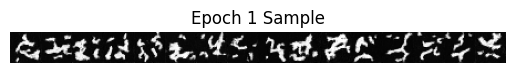

Epoch 2 | Loss: 0.0458: 100%|██████████| 938/938 [00:16<00:00, 56.08it/s]


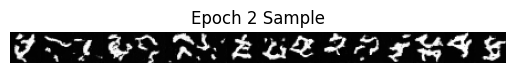

Epoch 3 | Loss: 0.0445: 100%|██████████| 938/938 [00:16<00:00, 56.20it/s]


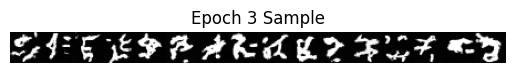

Epoch 4 | Loss: 0.0376: 100%|██████████| 938/938 [00:16<00:00, 55.75it/s]


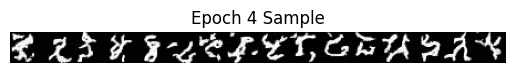

Epoch 5 | Loss: 0.0366: 100%|██████████| 938/938 [00:16<00:00, 55.76it/s]


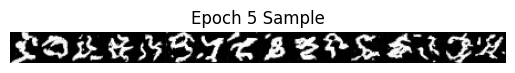

Epoch 6 | Loss: 0.0323: 100%|██████████| 938/938 [00:16<00:00, 55.96it/s]


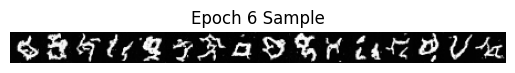

Epoch 7 | Loss: 0.0467: 100%|██████████| 938/938 [00:17<00:00, 54.67it/s]


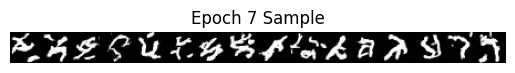

Epoch 8 | Loss: 0.0366: 100%|██████████| 938/938 [00:16<00:00, 55.37it/s]


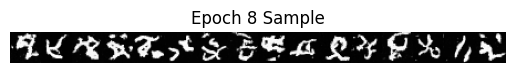

Epoch 9 | Loss: 0.0351: 100%|██████████| 938/938 [00:17<00:00, 55.12it/s]


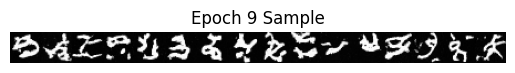

Epoch 10 | Loss: 0.0412: 100%|██████████| 938/938 [00:16<00:00, 55.41it/s]


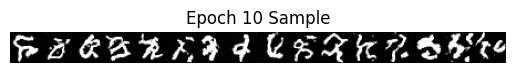

Epoch 11 | Loss: 0.0408: 100%|██████████| 938/938 [00:16<00:00, 55.73it/s]


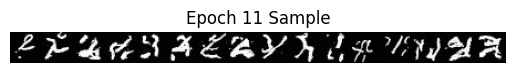

Epoch 12 | Loss: 0.0349: 100%|██████████| 938/938 [00:16<00:00, 55.32it/s]


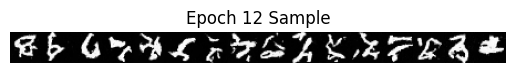

Epoch 13 | Loss: 0.0383: 100%|██████████| 938/938 [00:16<00:00, 55.27it/s]


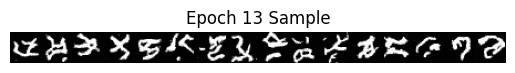

Epoch 14 | Loss: 0.0290: 100%|██████████| 938/938 [00:17<00:00, 54.32it/s]


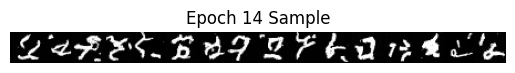

Epoch 15 | Loss: 0.0378: 100%|██████████| 938/938 [00:17<00:00, 55.05it/s]


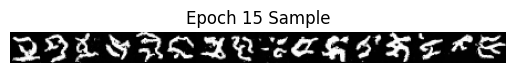

Epoch 16 | Loss: 0.0354: 100%|██████████| 938/938 [00:17<00:00, 54.58it/s]


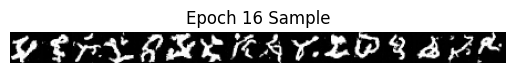

Epoch 17 | Loss: 0.0425: 100%|██████████| 938/938 [00:17<00:00, 54.42it/s]


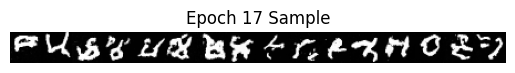

Epoch 18 | Loss: 0.0297: 100%|██████████| 938/938 [00:17<00:00, 54.56it/s]


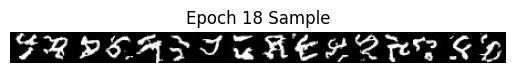

Epoch 19 | Loss: 0.0407: 100%|██████████| 938/938 [00:17<00:00, 54.55it/s]


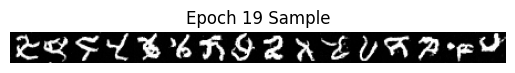

Epoch 20 | Loss: 0.0293: 100%|██████████| 938/938 [00:17<00:00, 54.65it/s]


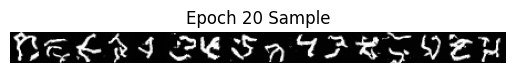

Epoch 21 | Loss: 0.0278: 100%|██████████| 938/938 [00:17<00:00, 54.66it/s]


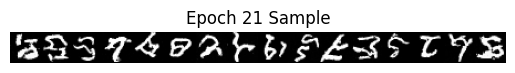

Epoch 22 | Loss: 0.0281: 100%|██████████| 938/938 [00:17<00:00, 54.20it/s]


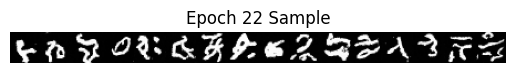

Epoch 23 | Loss: 0.0395: 100%|██████████| 938/938 [00:17<00:00, 54.32it/s]


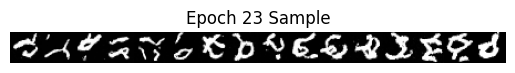

Epoch 24 | Loss: 0.0386: 100%|██████████| 938/938 [00:17<00:00, 54.06it/s]


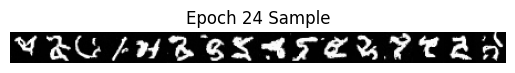

Epoch 25 | Loss: 0.0362: 100%|██████████| 938/938 [00:17<00:00, 53.91it/s]


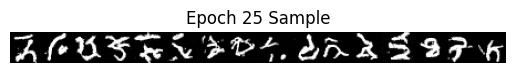

Epoch 26 | Loss: 0.0362: 100%|██████████| 938/938 [00:17<00:00, 54.56it/s]


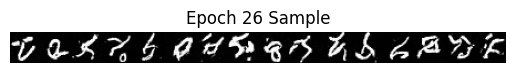

Epoch 27 | Loss: 0.0267: 100%|██████████| 938/938 [00:17<00:00, 54.17it/s]


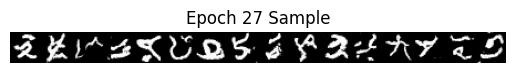

Epoch 28 | Loss: 0.0340: 100%|██████████| 938/938 [00:17<00:00, 54.45it/s]


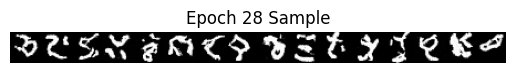

Epoch 29 | Loss: 0.0412: 100%|██████████| 938/938 [00:17<00:00, 54.14it/s]


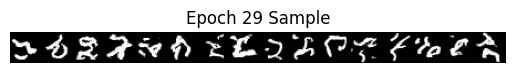

Epoch 30 | Loss: 0.0443: 100%|██████████| 938/938 [00:17<00:00, 54.47it/s]


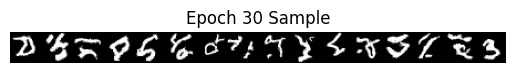

Epoch 31 | Loss: 0.0337: 100%|██████████| 938/938 [00:17<00:00, 53.62it/s]


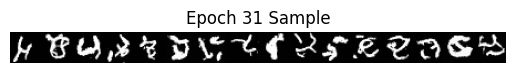

Epoch 32 | Loss: 0.0411: 100%|██████████| 938/938 [00:17<00:00, 53.88it/s]


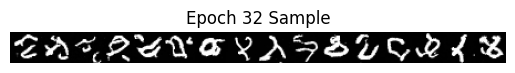

Epoch 33 | Loss: 0.0398: 100%|██████████| 938/938 [00:17<00:00, 53.56it/s]


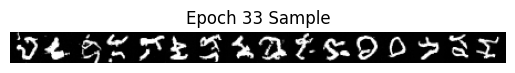

Epoch 34 | Loss: 0.0351: 100%|██████████| 938/938 [00:17<00:00, 53.50it/s]


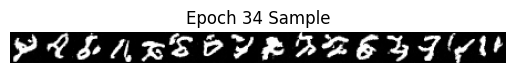

Epoch 35 | Loss: 0.0336: 100%|██████████| 938/938 [00:17<00:00, 54.04it/s]


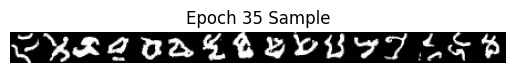

Epoch 36 | Loss: 0.0349: 100%|██████████| 938/938 [00:17<00:00, 54.06it/s]


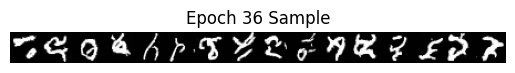

Epoch 37 | Loss: 0.0277: 100%|██████████| 938/938 [00:17<00:00, 53.95it/s]


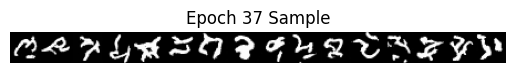

Epoch 38 | Loss: 0.0315: 100%|██████████| 938/938 [00:17<00:00, 53.69it/s]


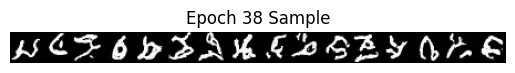

Epoch 39 | Loss: 0.0318: 100%|██████████| 938/938 [00:17<00:00, 54.06it/s]


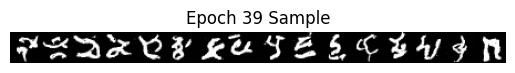

Epoch 40 | Loss: 0.0371: 100%|██████████| 938/938 [00:17<00:00, 54.00it/s]


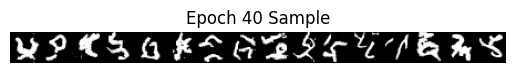

Epoch 41 | Loss: 0.0340: 100%|██████████| 938/938 [00:17<00:00, 54.19it/s]


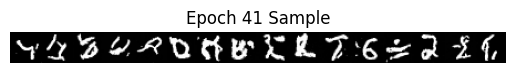

Epoch 42 | Loss: 0.0320: 100%|██████████| 938/938 [00:17<00:00, 53.86it/s]


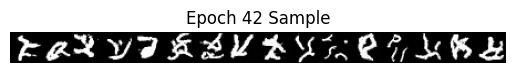

Epoch 43 | Loss: 0.0280: 100%|██████████| 938/938 [00:17<00:00, 54.09it/s]


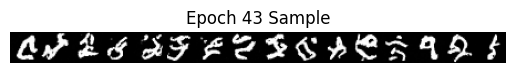

Epoch 44 | Loss: 0.0312: 100%|██████████| 938/938 [00:17<00:00, 54.09it/s]


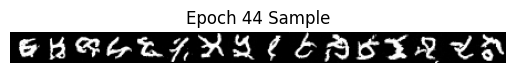

Epoch 45 | Loss: 0.0252: 100%|██████████| 938/938 [00:17<00:00, 53.79it/s]


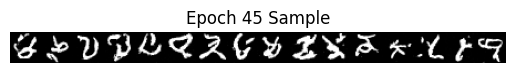

Epoch 46 | Loss: 0.0275: 100%|██████████| 938/938 [00:17<00:00, 53.02it/s]


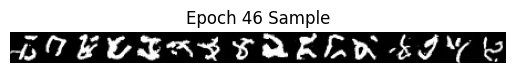

Epoch 47 | Loss: 0.0328: 100%|██████████| 938/938 [00:17<00:00, 54.04it/s]


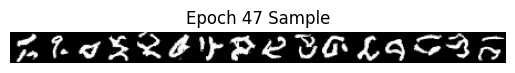

Epoch 48 | Loss: 0.0379: 100%|██████████| 938/938 [00:17<00:00, 54.14it/s]


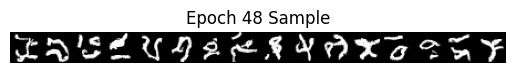

Epoch 49 | Loss: 0.0324: 100%|██████████| 938/938 [00:17<00:00, 54.20it/s]


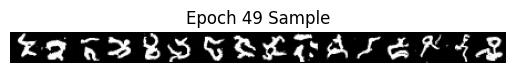

Epoch 50 | Loss: 0.0326: 100%|██████████| 938/938 [00:17<00:00, 53.93it/s]


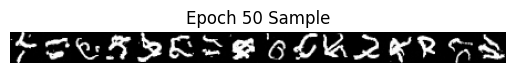

Epoch 51 | Loss: 0.0335: 100%|██████████| 938/938 [00:17<00:00, 53.70it/s]


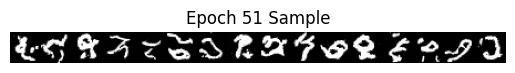

Epoch 52 | Loss: 0.0243: 100%|██████████| 938/938 [00:17<00:00, 53.60it/s]


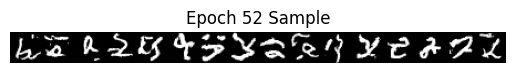

Epoch 53 | Loss: 0.0331: 100%|██████████| 938/938 [00:17<00:00, 53.13it/s]


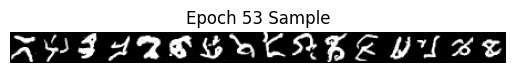

Epoch 54 | Loss: 0.0317: 100%|██████████| 938/938 [00:17<00:00, 53.57it/s]


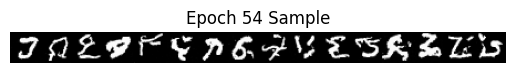

Epoch 55 | Loss: 0.0399: 100%|██████████| 938/938 [00:17<00:00, 53.45it/s]


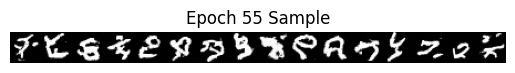

Epoch 56 | Loss: 0.0311: 100%|██████████| 938/938 [00:17<00:00, 52.68it/s]


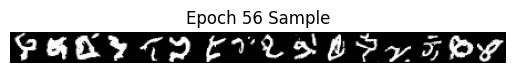

Epoch 57 | Loss: 0.0346: 100%|██████████| 938/938 [00:17<00:00, 52.27it/s]


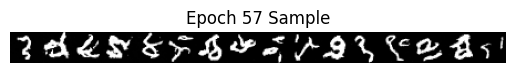

Epoch 58 | Loss: 0.0264: 100%|██████████| 938/938 [00:17<00:00, 52.93it/s]


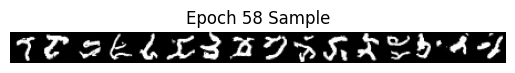

Epoch 59 | Loss: 0.0331: 100%|██████████| 938/938 [00:17<00:00, 53.12it/s]


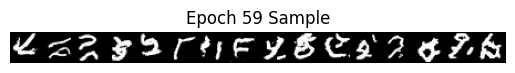

Epoch 60 | Loss: 0.0303: 100%|██████████| 938/938 [00:17<00:00, 52.20it/s]


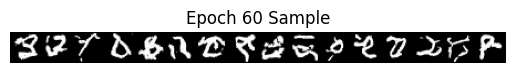

Epoch 61 | Loss: 0.0316: 100%|██████████| 938/938 [00:17<00:00, 52.58it/s]


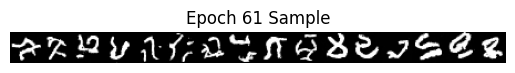

Epoch 62 | Loss: 0.0256: 100%|██████████| 938/938 [00:17<00:00, 52.56it/s]


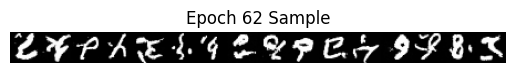

Epoch 63 | Loss: 0.0370: 100%|██████████| 938/938 [00:17<00:00, 52.43it/s]


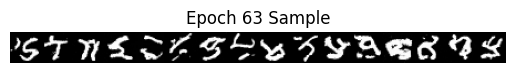

Epoch 64 | Loss: 0.0369: 100%|██████████| 938/938 [00:18<00:00, 52.07it/s]


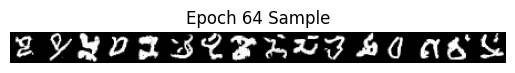

Epoch 65 | Loss: 0.0404: 100%|██████████| 938/938 [00:17<00:00, 52.35it/s]


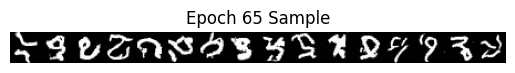

Epoch 66 | Loss: 0.0248: 100%|██████████| 938/938 [00:17<00:00, 52.13it/s]


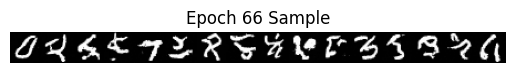

Epoch 67 | Loss: 0.0311: 100%|██████████| 938/938 [00:18<00:00, 52.09it/s]


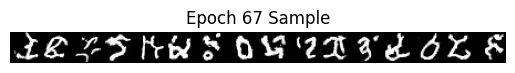

Epoch 68 | Loss: 0.0292: 100%|██████████| 938/938 [00:17<00:00, 52.18it/s]


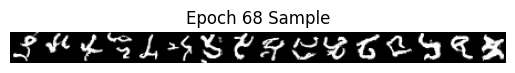

Epoch 69 | Loss: 0.0296: 100%|██████████| 938/938 [00:17<00:00, 52.19it/s]


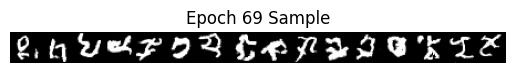

Epoch 70 | Loss: 0.0401: 100%|██████████| 938/938 [00:17<00:00, 52.24it/s]


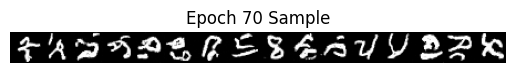

Epoch 71 | Loss: 0.0368: 100%|██████████| 938/938 [00:17<00:00, 52.64it/s]


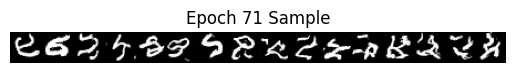

Epoch 72 | Loss: 0.0380: 100%|██████████| 938/938 [00:17<00:00, 52.47it/s]


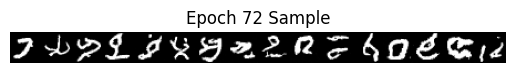

Epoch 73 | Loss: 0.0441: 100%|██████████| 938/938 [00:17<00:00, 52.34it/s]


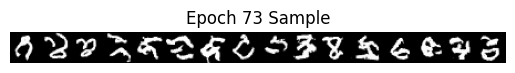

Epoch 74 | Loss: 0.0305: 100%|██████████| 938/938 [00:17<00:00, 52.32it/s]


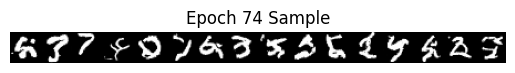

Epoch 75 | Loss: 0.0294: 100%|██████████| 938/938 [00:17<00:00, 52.77it/s]


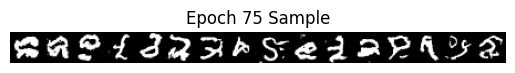

Epoch 76 | Loss: 0.0326: 100%|██████████| 938/938 [00:17<00:00, 52.75it/s]


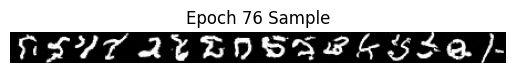

Epoch 77 | Loss: 0.0391: 100%|██████████| 938/938 [00:18<00:00, 52.04it/s]


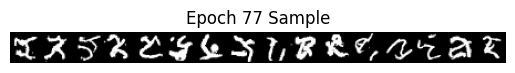

Epoch 78 | Loss: 0.0416: 100%|██████████| 938/938 [00:17<00:00, 52.82it/s]


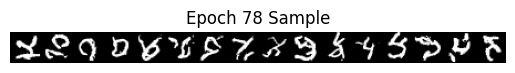

Epoch 79 | Loss: 0.0351: 100%|██████████| 938/938 [00:17<00:00, 52.81it/s]


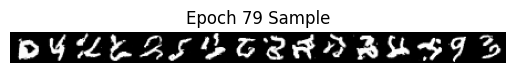

Epoch 80 | Loss: 0.0359: 100%|██████████| 938/938 [00:17<00:00, 52.58it/s]


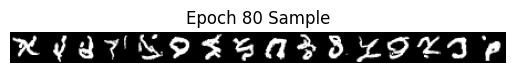

Epoch 81 | Loss: 0.0340: 100%|██████████| 938/938 [00:17<00:00, 53.29it/s]


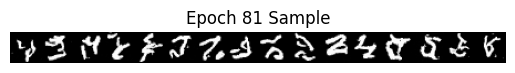

Epoch 82 | Loss: 0.0279: 100%|██████████| 938/938 [00:17<00:00, 52.86it/s]


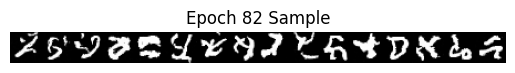

Epoch 83 | Loss: 0.0323: 100%|██████████| 938/938 [00:17<00:00, 53.10it/s]


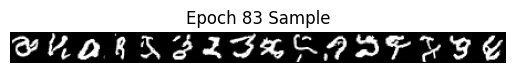

Epoch 84 | Loss: 0.0333: 100%|██████████| 938/938 [00:17<00:00, 52.65it/s]


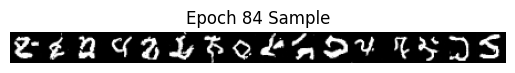

Epoch 85 | Loss: 0.0236: 100%|██████████| 938/938 [00:17<00:00, 52.84it/s]


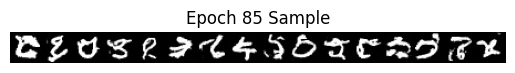

Epoch 86 | Loss: 0.0329: 100%|██████████| 938/938 [00:17<00:00, 53.19it/s]


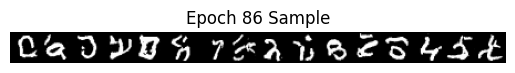

Epoch 87 | Loss: 0.0264: 100%|██████████| 938/938 [00:17<00:00, 52.79it/s]


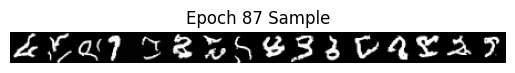

Epoch 88 | Loss: 0.0292: 100%|██████████| 938/938 [00:17<00:00, 53.04it/s]


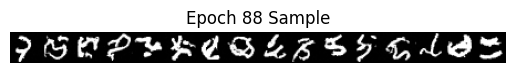

Epoch 89 | Loss: 0.0276: 100%|██████████| 938/938 [00:17<00:00, 52.83it/s]


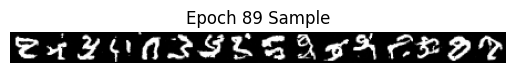

Epoch 90 | Loss: 0.0318: 100%|██████████| 938/938 [00:17<00:00, 52.78it/s]


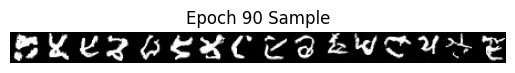

Epoch 91 | Loss: 0.0226: 100%|██████████| 938/938 [00:17<00:00, 53.18it/s]


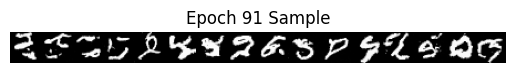

Epoch 92 | Loss: 0.0288: 100%|██████████| 938/938 [00:17<00:00, 52.82it/s]


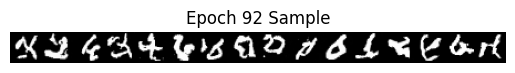

Epoch 93 | Loss: 0.0274: 100%|██████████| 938/938 [00:17<00:00, 53.07it/s]


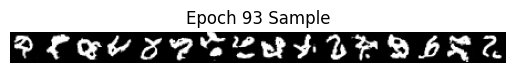

Epoch 94 | Loss: 0.0300: 100%|██████████| 938/938 [00:17<00:00, 52.41it/s]


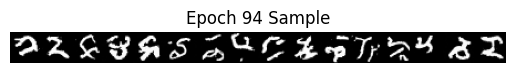

Epoch 95 | Loss: 0.0403: 100%|██████████| 938/938 [00:17<00:00, 52.87it/s]


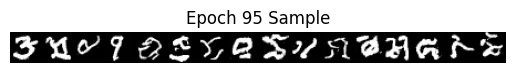

Epoch 96 | Loss: 0.0309: 100%|██████████| 938/938 [00:17<00:00, 53.18it/s]


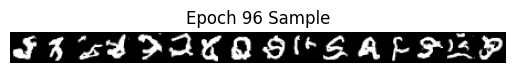

Epoch 97 | Loss: 0.0218: 100%|██████████| 938/938 [00:17<00:00, 53.08it/s]


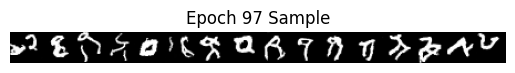

Epoch 98 | Loss: 0.0482: 100%|██████████| 938/938 [00:17<00:00, 54.00it/s]


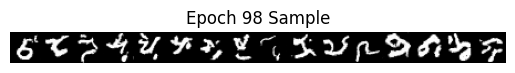

Epoch 99 | Loss: 0.0340: 100%|██████████| 938/938 [00:17<00:00, 53.17it/s]


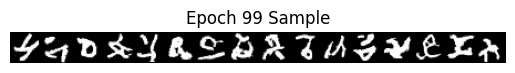

Epoch 100 | Loss: 0.0264: 100%|██████████| 938/938 [00:17<00:00, 52.74it/s]


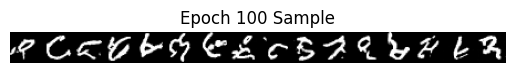

In [17]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 정의 (사용자 정의 UNet)
model = SimpleUNet().to(device)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
trainer = DDIMTrainer(model, timesteps=200, eta=0.0)

# 학습 루프
for epoch in range(100):
    model.train()
    pbar = tqdm(train_loader)
    for batch in pbar:
        x, _ = batch
        x = x.to(device)

        optimizer.zero_grad()
        loss = trainer.train_step(x)
        loss.backward()
        optimizer.step()

        pbar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

    # 샘플링 및 시각화
    model.eval()
    samples = trainer.sample_ddim((16, 1, 28, 28))

    import matplotlib.pyplot as plt
    grid = torch.cat([s.squeeze().cpu() + 0.5 for s in samples], dim=-1)
    plt.imshow(grid.numpy(), cmap='gray')
    plt.title(f"Epoch {epoch+1} Sample")
    plt.axis('off')
    plt.show()